## Часть 1 — Доделываем семинар и получаем SNP

Ниже приведена история терминала WSL по выполнению этого задания, записанная в txt-файл

In [65]:
with open('commands.txt', 'r', encoding='utf-8') as file:
    for line in file:
        print(line.strip())

354  mkdir -p genome_alignment_work/{data,results,scripts}
355  ls
356  cd genome_alignment_work
357  ls
358  cd data
359  wget -O ecoli_k12.fna.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz"
360  wget -O ecoli_o157.fna.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/008/865/GCF_000008865.2_ASM886v2/GCF_000008865.2_ASM886v2_genomic.fna.gz"
361  gunzip *.fna.gz
362  wget -O ecoli_k12.gbff.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz"
363  gunzip ecoli_k12.gbff.gz
364  ls -lh
365  cd ../results
366  nucmer --prefix=ecoli_opt --maxmatch --mincluster=100 --diagfactor=0.12        ../data/ecoli_k12.fna ../data/ecoli_o157.fna
367  show-snps -r -C -T ecoli_opt.delta > snps.tsv
368  head -5 snps.tsv


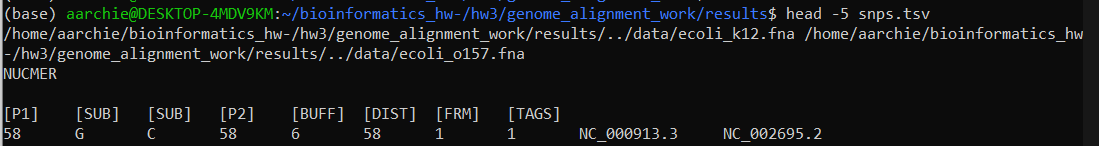

Разберем названия полученных столбцов:

 - [P1] — Позиция измененного нуклеотида в первом геноме
 - [SUB] — Нуклеотид, который находится в этой позиции в первом геноме
 - [SUB] — Нуклеотид, на который он заменился во втором геноме
 - [P2] — Позиция измененного нуклеотида во втором геноме
 - [BUFF] — Расстояние от данного SNP до ближайшего другого несовпадения в этом же выравнивании
 - [DIST] — Расстояние от данного SNP до ближайшего края выравнивания 
 - [FRM] — Направление чтения прямой или обратной цепи для обоих геномов. 1 - прямая цепь
 - [TAGS] — Идентификаторы последовательностей из первого и второго файлов

## Часть 2 — Аннотация SNP

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Seq import Seq
import seaborn as sns
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore')

In [68]:
DATA_PATH_ECOLI_K12 = "ecoli_k12.gbff"
DATA_PATH_SNPS = "snps.tsv"

genbank_record = SeqIO.read(DATA_PATH_ECOLI_K12, "genbank")
genome_sequence = genbank_record.seq
cds_features = [x for x in genbank_record.features if x.type == "CDS"]

df = pd.read_csv(DATA_PATH_SNPS, sep='\t', skiprows=4, header=None)
df.columns = ['P1', 'REF', 'ALT', 'P2', 'BUFF', 'DIST', 'FRM_R', 'FRM_Q', 'TAG_R', 'TAG_Q']

In [69]:
df

,P1,REF,ALT,P2,BUFF,DIST,FRM_R,FRM_Q,TAG_R,TAG_Q
0,58,G,C,58,6,58,1,1,NC_000913.3,NC_002695.2
1,64,T,C,64,6,64,1,1,NC_000913.3,NC_002695.2
2,228,.,A,229,0,228,1,1,NC_000913.3,NC_002695.2
3,228,.,C,230,0,228,1,1,NC_000913.3,NC_002695.2
4,228,.,C,231,0,228,1,1,NC_000913.3,NC_002695.2
...,...,...,...,...,...,...,...,...,...,...
73546,4641411,C,T,5498337,17,242,1,1,NC_000913.3,NC_002695.2
73547,4641428,G,A,5498354,11,225,1,1,NC_000913.3,NC_002695.2
73548,4641439,T,C,5498365,1,214,1,1,NC_000913.3,NC_002695.2
73549,4641440,G,A,5498366,1,213,1,1,NC_000913.3,NC_002695.2


In [51]:
results = []

for idx, row in tqdm(df.iterrows(), total=df.shape[0]):
    
    position = int(row['P1'])
    ref = str(row['REF']).upper()
    alt = str(row['ALT']).upper()
    
    if (ref == '.') or (alt == '.'):
        continue

    gene_name = "Intergenic"
    product = "None"
    mutation = "Intergenic"
    change = "-"
    
    zero_based_pos = position - 1
    
    for cds in cds_features:
        
        if zero_based_pos in cds:
            
            gene_name = cds.qualifiers.get('gene', cds.qualifiers.get('locus_tag', ['Unknown']))[0]
            product = cds.qualifiers.get('product', ['Unknown'])[0]
            
            strand = cds.location.strand
            start = cds.location.start
            end = cds.location.end
            
            if strand == 1:
                offset = zero_based_pos - start
                codon_index = offset // 3
                pos_in_codon = offset % 3
                codon_start = start + codon_index * 3
                ref_codon = genome_sequence[codon_start : codon_start + 3]
                
                alt_codon_list = list(ref_codon)
                alt_codon_list[pos_in_codon] = alt
                alt_codon = Seq("".join(alt_codon_list))
                
            else:
                offset = (end - 1) - zero_based_pos
                codon_index = offset // 3
                pos_in_codon = offset % 3
                codon_start = end - (codon_index + 1) * 3
                ref_codon = genome_sequence[codon_start : codon_start + 3].reverse_complement()
                
                alt_codon_list = list(ref_codon)
                alt_codon_list[pos_in_codon] = str(Seq(alt).complement())
                alt_codon = Seq("".join(alt_codon_list))

            try:
                
                ref_aa = ref_codon.translate()
                alt_aa = alt_codon.translate()
                
                if ref_aa == alt_aa:
                    mutation = "Synonymous"
                else:
                    mutation = "Non-synonymous"
                
                aa_position = codon_index + 1
                change = f"p.{ref_aa}{aa_position}{alt_aa}"
                
            except Exception as e:
                
                mutation = "Error"
            
            break
            
    results.append({
        'Position': position,
        'Ref': ref,
        'Alt': alt,
        'Gene': gene_name,
        'Product': product,
        'Type': mutation,
        'AA_Change': change
    })

  0%|          | 0/73551 [00:00<?, ?it/s]

In [52]:
annotated_snps = pd.DataFrame(results)
annotated_snps.head(10)

,Position,Ref,Alt,Gene,Product,Type,AA_Change
0,58,G,C,Intergenic,None,Intergenic,-
1,64,T,C,Intergenic,None,Intergenic,-
2,393,T,G,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.R19R
3,559,T,C,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.L75L
4,588,G,A,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.G84G
5,621,T,C,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.D95D
6,669,G,A,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.L111L
7,690,C,T,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.I118I
8,774,T,C,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.T146T
9,828,C,T,thrA,fused aspartate kinase/homoserine dehydrogenase 1,Synonymous,p.T164T


### Таблица Топ-10 генов с наибольшим количеством SNP

In [84]:
gene_counts = annotated_snps[annotated_snps['Gene'].notna()]['Gene'].value_counts().head(10)
print("=== Top-10 genes with biggest number of SNPs ===")
top10_table = pd.DataFrame({'Gene': gene_counts.index, 'SNP_count': gene_counts.values})
print(top10_table.to_string(index=False))

=== Top-10 genes with biggest number of SNPs ===
      Gene  SNP_count
Intergenic       8952
      ybgQ        430
      yehB        301
      yeeJ        240
      ybgO        218
      yehI        191
      ybgP        165
      ydbA        164
      afuC        145
      yjgL        139


### График плотности SNP с наложением позиций генов

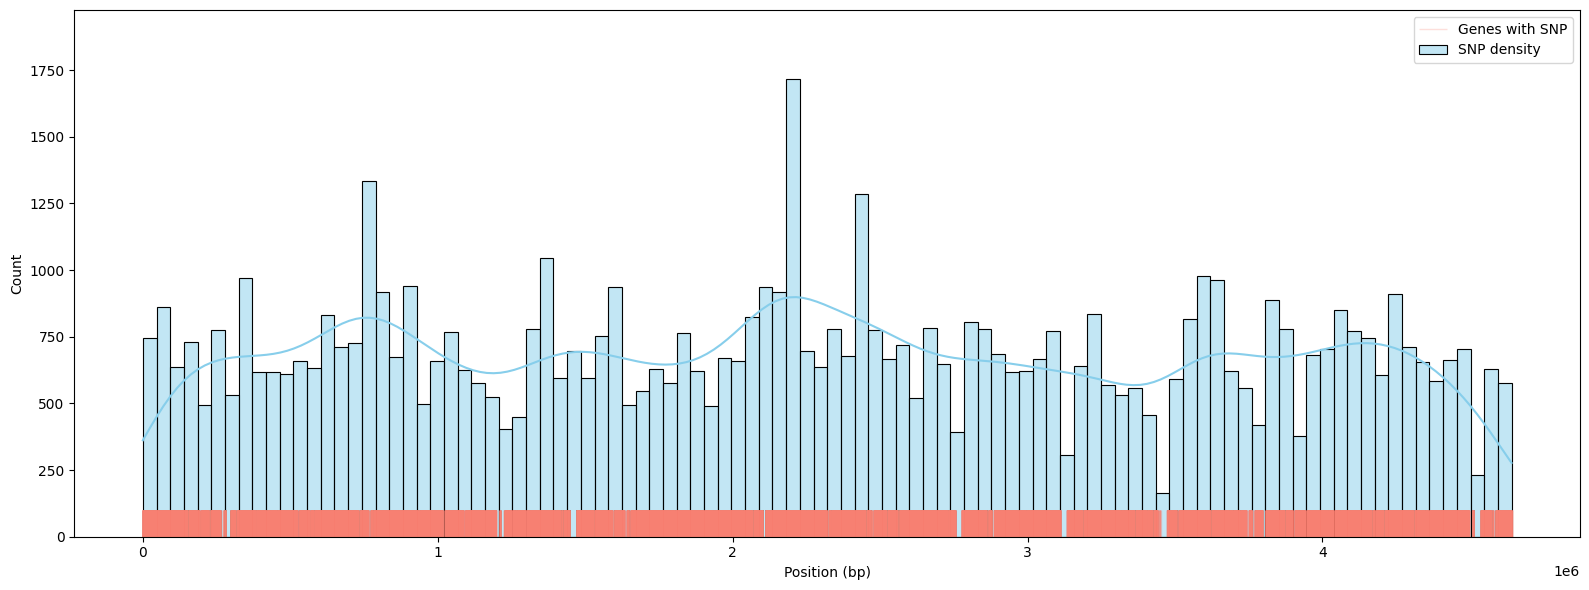

In [61]:
plt.figure(figsize=(16, 6))

sns.histplot(data=annotated_snps['Position'], bins=100, kde=True, label='SNP density', color='skyblue')
gene_positions = annotated_snps[annotated_snps['Gene'] != 'Intergenic']['Position']
sns.rugplot(gene_positions, height=0.05, color='salmon', alpha=0.25, label='Genes with SNP')
plt.xlabel('Position (bp)')
plt.legend()
plt.tight_layout()
plt.show()

### Диаграмма распределения типов SNP

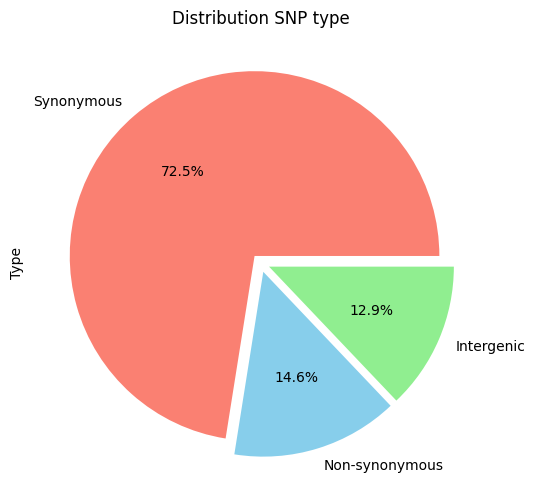

In [64]:
type_counts = annotated_snps['Type'].value_counts()
plt.figure(figsize=(8, 6))
type_counts.plot(kind='pie', autopct='%1.1f%%', explode=[0.05]*len(type_counts), colors=['salmon', 'skyblue', 'lightgreen'])
plt.title('Distribution SNP type')
plt.show()

## Часть 3 — Поиск функционально значимых SNP 

В статье Study of heavy metal resistance genes in Escherichia coli isolates from a marine ecosystem with a history of environmental pollution (arsenic, cadmium, copper, and mercury)  [https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0294565] приведен список изучаемых HMRGs (генов с резистентностью к тяжелым металлам)

### Фильтрация

In [71]:
heavy_metal_genes = [
    # arsenic
    "arsB", "arsC", "arsD", "arsR",
    # cadmium/mercury
    "dsbA", "dsbB", "robA",
    # cadmium
    "ygiW", "zinT", "yodA",
    # copper
    "bhsA", "ycfR", "comC", "comR", "ycfQ", "cusR", "ylcA", "cusS", "cutA", "cutC", "cutF", "nlpE", "dsbC", "pcoA", "pcoB", "pcoC", "pcoD"
]

In [85]:
hm_snps = annotated_snps[annotated_snps['Gene'].str.lower().isin([g.lower() for g in heavy_metal_genes])]

print(f"{len(hm_snps)} SNP in heavy metal resistance genes")
print("="*50)
hm_snps

191 SNP in heavy metal resistance genes


,Position,Ref,Alt,Gene,Product,Type,AA_Change
3293,215328,A,T,nlpE,sensor lipoprotein NlpE,Synonymous,p.G20G
3294,215380,C,T,nlpE,sensor lipoprotein NlpE,Synonymous,p.L38L
3295,215677,G,C,nlpE,sensor lipoprotein NlpE,Non-synonymous,p.A137P
3296,215697,T,C,nlpE,sensor lipoprotein NlpE,Synonymous,p.P143P
3297,215812,A,G,nlpE,sensor lipoprotein NlpE,Non-synonymous,p.S182G
...,...,...,...,...,...,...,...
60772,4043786,T,A,dsbA,thiol:disulfide oxidoreductase DsbA,Synonymous,p.S123S
60773,4043789,T,A,dsbA,thiol:disulfide oxidoreductase DsbA,Synonymous,p.A124A
60774,4043921,C,T,dsbA,thiol:disulfide oxidoreductase DsbA,Synonymous,p.G168G
66021,4365300,T,C,cutA,copper binding protein CutA,Synonymous,p.P19P


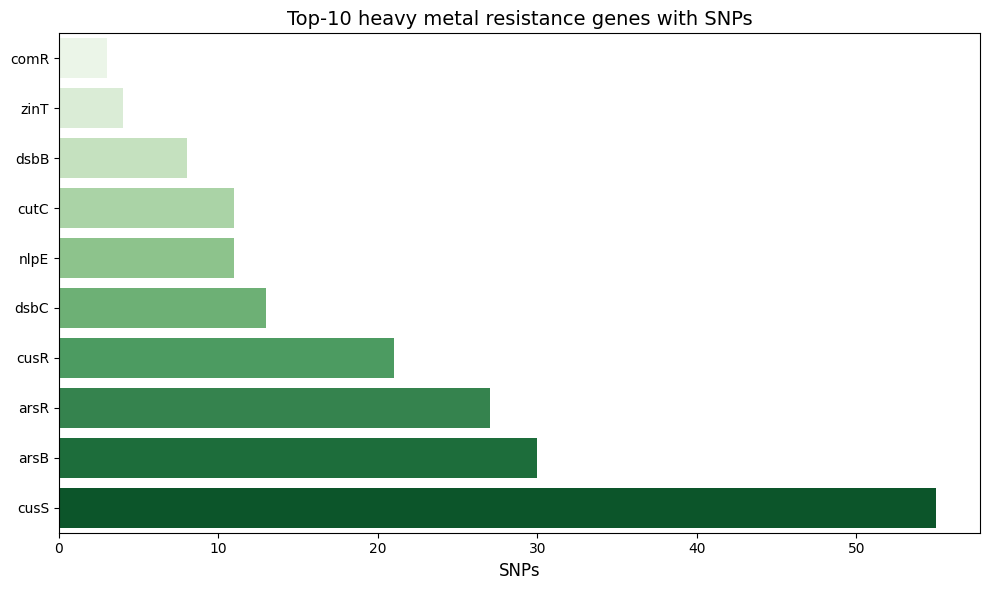

In [86]:
hm_counts = hm_snps['Gene'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=hm_counts.values[::-1], y=hm_counts.index[::-1], palette='Greens')
plt.xlabel('SNPs', fontsize=12)
plt.title('Top-10 heavy metal resistance genes with SNPs', fontsize=14)
plt.tight_layout()

### Мысли и рассуждения

 - Высокое количество мутаций в генах устойчивости к тяжелым металлам может указывать на долгое нахождение в загрязненной среде, то есть генетический профиль бактерий может быть использован для оценки уровня промышленного загрязнения почв или водоемов
 - Выявление наиболее эффективных штаммов-мутантов для создания биофильтров, которые будут поглощать или нейтрализовать тяжелые металлы